<a href="https://colab.research.google.com/github/ApexShadow28/Machine-Learning/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


None

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


Missing Values:
 network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


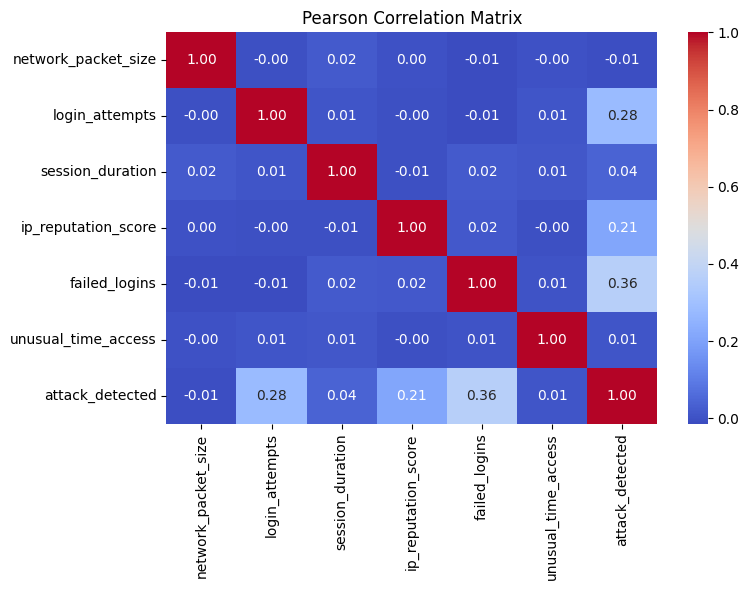

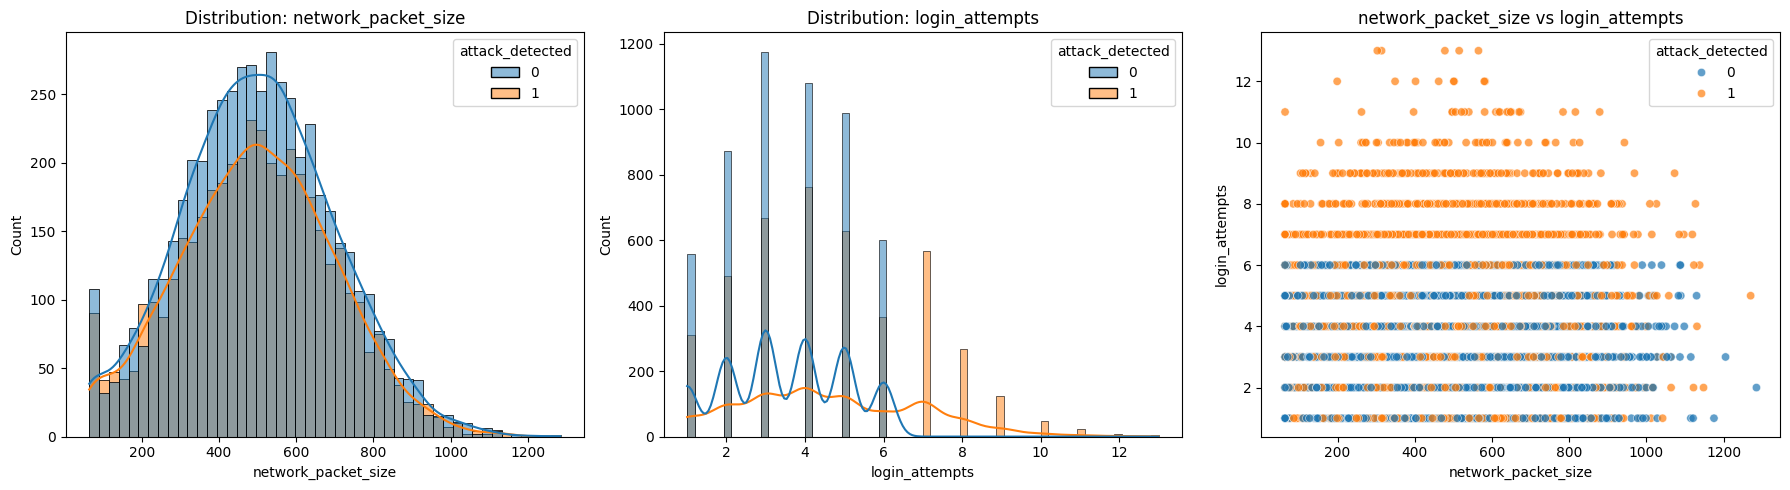

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Load Data & Structural Inspection
df = pd.read_csv('cybersecurity_intrusion_data.csv')
display(df.head(), df.info(), df.describe())

# Drop non-informative IDs if present
id_cols = [c for c in df.columns if 'id' in c.lower() and c != 'attack_detected']
df.drop(columns=id_cols, inplace=True, errors='ignore')

# 2. Quantify Missing Values & Separate Features/Target
print("Missing Values:\n", df.isnull().sum())

X = df.drop(columns=['attack_detected'])
y = df['attack_detected']

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Construct Preprocessing Pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

X_preprocessed = preprocessor.fit_transform(X)

# 4. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['attack_detected']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# 5. Required Visualizations (2 Distribution Plots, 1 Scatter Plot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x=num_cols[0], hue='attack_detected', kde=True, ax=axes[0])
axes[0].set_title(f"Distribution: {num_cols[0]}")

sns.histplot(data=df, x=num_cols[1], hue='attack_detected', kde=True, ax=axes[1])
axes[1].set_title(f"Distribution: {num_cols[1]}")

sns.scatterplot(data=df, x=num_cols[0], y=num_cols[1], hue='attack_detected', alpha=0.7, ax=axes[2])
axes[2].set_title(f"{num_cols[0]} vs {num_cols[1]}")

plt.tight_layout()
plt.show()

Manually inspecting the schema design, pattern of missing values, and data type of the columns is needed prior to designing a pipeline for loading the raw datasets from external sources. As opposed to pre-packaged datasets where they are all clean, pre-formatted, and ready to use in terms of splitting, raw Kaggle datasets may include non-informational tracking IDs (e.g., session_id).

Evaluating df.isnull().sum() revealed that encryption_used contained $1,966 missing values (roughly 20.6% of rows), while all numerical features were fully populated. Because encryption_used is a categorical column representing protocol security, dropping rows would lose over a fifth of the dataset. Replacing missing entries with the most frequent category (strategy='most_frequent') via Scikit-Learn's SimpleImputer preserves dataset integrity without skewing continuous numerical attributes.

ColumnTransformer and Pipeline ensure that the missing value imputation, numerical normalization using StandardScaler, and categorical variable encoding through OneHotEncoder are all performed together within a single execution graph. In this way, data leakage does not occur since all the parameters for the transformations are computed during .fit() of the training folds only.

The feature variables that have high correlation with the target variable are failed logins (r = 0.36), login attempts (r = 0.28) and ip reputation score (r = 0.21). From an operational perspective, it is clear that attacks are motivated by brute force login attempts as well as the presence of traffic from malicious IPs. Network packet size (r = -0.01) shows practically zero correlation with the target feature.